Mean Squared Error: 7.444


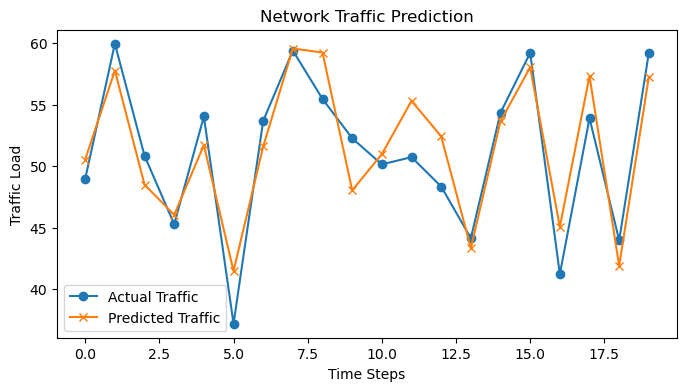

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
# Generate synthetic traffic data
time = np.arange(0, 100, 1)
traffic = 50 + 10 * np.sin(time / 5) + np.random.normal(0, 2, len(time))
# Prepare dataset
data = pd.DataFrame({'time': time, 'traffic': traffic})
data['lag_1'] = data['traffic'].shift(1)
data = data.dropna()
X = data[['lag_1']]
y = data['traffic']
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)
# Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)
# Predictions
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.3f}")
# Visualization
plt.figure(figsize=(8,4))
plt.plot(y_test.values, label='Actual Traffic', marker='o')
plt.plot(y_pred, label='Predicted Traffic', marker='x')
plt.title('Network Traffic Prediction')
plt.xlabel('Time Steps')
plt.ylabel('Traffic Load')
plt.legend()
plt.show()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RNG_SEED = 7
np.random.seed(RNG_SEED)

REROUTE_THRESHOLD = 75  # % load at which we'd want to preemptively reroute


def generate_traffic_log(num_points=500, points_per_day=48):
    """
    Builds a synthetic traffic series meant to look like packets/sec load
    on a router, sampled every 30 minutes. Includes:
      - a daily usage cycle (busy in the evening, quiet overnight)
      - a slow upward trend (as if usage is growing over the weeks)
      - random bursts (simulating spikes from background jobs, updates, etc.)
      - gaussian noise
    """
    t = np.arange(num_points)

    daily_cycle = 20 * np.sin((2 * np.pi / points_per_day) * t - np.pi / 2) + 20
    trend = t * 0.03
    bursts = np.zeros(num_points)
    burst_idxs = np.random.choice(num_points, size=num_points // 25, replace=False)
    bursts[burst_idxs] = np.random.uniform(15, 35, size=len(burst_idxs))
    noise = np.random.normal(0, 3, num_points)

    load = 30 + daily_cycle + trend + bursts + noise
    load = np.clip(load, 0, 100)

    start = pd.Timestamp("2026-06-01")
    timestamps = [start + pd.Timedelta(minutes=30 * i) for i in range(num_points)]

    df = pd.DataFrame({"timestamp": timestamps, "load": load})
    return df


def add_features(df):
    """Adds lag, rolling-window, and time-of-day features."""
    df = df.copy()
    df["hour"] = df["timestamp"].dt.hour + df["timestamp"].dt.minute / 60
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    for lag in (1, 2, 3):
        df[f"lag_{lag}"] = df["load"].shift(lag)

    df["rolling_mean_3"] = df["load"].shift(1).rolling(window=3).mean()
    df["rolling_std_3"] = df["load"].shift(1).rolling(window=3).std()

    df = df.dropna().reset_index(drop=True)
    return df


def train_models(X_train, y_train):
    models = {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(
            n_estimators=200, max_depth=6, random_state=RNG_SEED
        ),
    }
    for model in models.values():
        model.fit(X_train, y_train)
    return models


def evaluate_models(models, X_test, y_test):
    results = {}
    for name, model in models.items():
        preds = model.predict(X_test)
        results[name] = {
            "predictions": preds,
            "mse": mean_squared_error(y_test, preds),
            "mae": mean_absolute_error(y_test, preds),
            "r2": r2_score(y_test, preds),
        }
    return results


def simulate_rerouting(y_test, best_preds, threshold=REROUTE_THRESHOLD, max_log=8):
    """
    Walks through the predicted loads and prints a short log of moments
    where the model would have told a router to reroute traffic *before*
    the actual congestion hit -- i.e. predictive vs. reactive routing.
    """
    y_test_arr = y_test.reset_index(drop=True)
    logged = 0
    print("\n--- Simulated Predictive Routing Log ---")
    for i, pred in enumerate(best_preds):
        if pred >= threshold:
            actual = y_test_arr[i]
            flag = "would have preempted congestion" if actual >= threshold * 0.9 else "false alarm"
            print(f"t={i:>3}  predicted={pred:5.1f}%  actual={actual:5.1f}%  -> {flag}")
            logged += 1
        if logged >= max_log:
            break
    if logged == 0:
        print("No predicted load crossed the reroute threshold in this test window.")


def main():
    df = generate_traffic_log()
    df = add_features(df)

    feature_cols = ["hour_sin", "hour_cos", "lag_1", "lag_2", "lag_3",
                     "rolling_mean_3", "rolling_std_3"]
    X = df[feature_cols]
    y = df["load"]

    # Chronological split -- don't shuffle time series data
    split_idx = int(len(df) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    models = train_models(X_train, y_train)
    results = evaluate_models(models, X_test, y_test)

    print("Model performance on held-out test window:")
    for name, res in results.items():
        print(f"  {name:<18} MSE={res['mse']:6.2f}  MAE={res['mae']:5.2f}  R2={res['r2']:.3f}")

    best_name = min(results, key=lambda n: results[n]["mse"])
    print(f"\nBest model by MSE: {best_name}")

    simulate_rerouting(y_test, results[best_name]["predictions"])

    # Plot: actual vs predicted (best model)
    plt.figure(figsize=(10, 4.5))
    plt.plot(y_test.values, label="Actual Load", marker="o", markersize=3, linewidth=1)
    plt.plot(results[best_name]["predictions"], label=f"Predicted ({best_name})",
              marker="x", markersize=3, linewidth=1)
    plt.axhline(REROUTE_THRESHOLD, color="red", linestyle="--", linewidth=1,
                label="Reroute Threshold")
    plt.title("Network Traffic Prediction vs. Actual")
    plt.xlabel("Time Step (test window)")
    plt.ylabel("Router Load (%)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("traffic_predictions.png", dpi=150)
    plt.close()

    # Plot: model comparison
    names = list(results.keys())
    mses = [results[n]["mse"] for n in names]
    plt.figure(figsize=(6, 4))
    plt.bar(names, mses, color=["#4C72B0", "#DD8452"])
    plt.title("Model Comparison (lower MSE is better)")
    plt.ylabel("Mean Squared Error")
    plt.tight_layout()
    plt.savefig("model_comparison.png", dpi=150)
    plt.close()

    print("\nSaved traffic_predictions.png and model_comparison.png")


if __name__ == "__main__":
    main()

Model performance on held-out test window:
  Linear Regression  MSE= 67.34  MAE= 4.96  R2=0.709
  Random Forest      MSE= 76.46  MAE= 5.48  R2=0.669

Best model by MSE: Linear Regression

--- Simulated Predictive Routing Log ---
t=  3  predicted= 79.0%  actual= 69.0%  -> would have preempted congestion
t=  4  predicted= 76.1%  actual= 79.3%  -> would have preempted congestion
t=  5  predicted= 76.4%  actual= 82.5%  -> would have preempted congestion
t=  6  predicted= 77.0%  actual= 84.9%  -> would have preempted congestion
t=  7  predicted= 82.6%  actual= 80.0%  -> would have preempted congestion
t=  8  predicted= 82.4%  actual= 80.3%  -> would have preempted congestion
t=  9  predicted= 81.3%  actual= 80.8%  -> would have preempted congestion
t= 10  predicted= 80.6%  actual= 84.1%  -> would have preempted congestion

Saved traffic_predictions.png and model_comparison.png
